In [158]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [42]:
df = pd.read_csv("C:\\Users\\user\\Desktop\\Colab Notebooks\\Customer churn prediction\\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [43]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


# Data preparation

## Making everything uniform

In [44]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [45]:
df.head(5)

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [46]:
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges            str
churn                   str
dtype: object

## Fixing the totalcharges column

In [47]:
tc = pd.to_numeric(df.totalcharges, errors='coerce')

In [48]:
tc.isnull().sum()

np.int64(11)

In [49]:
df[tc.isnull()][['customerid', 'totalcharges']]

,customerid,totalcharges
488,4472-LVYGI,
753,3115-CZMZD,
936,5709-LVOEQ,
1082,4367-NUYAO,
1340,1371-DWPAZ,
3331,7644-OMVMY,
3826,3213-VVOLG,
4380,2520-SGTTA,
5218,2923-ARZLG,
6670,4075-WKNIU,


In [50]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

## Encoding the target variable

In [51]:
df.churn.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: churn, dtype: str

In [52]:
df.churn = (df.churn == 'Yes').astype(int)

In [53]:
df['churn'].value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

In [54]:
df.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

# Setting up the validation framework

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)

In [57]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [58]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

## Resetting the index

In [59]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

## Isolating the target

In [60]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [61]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

# EDA

In [62]:
df_full_train = df_full_train.reset_index(drop=True)

In [63]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

## Looking at the target: the churn rate
we look at the target variable - how many customers churned and how many stayed

In [64]:
df_full_train.churn.value_counts(normalize=True)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [65]:
df_full_train.churn.mean()

np.float64(0.26996805111821087)

In [66]:
df_full_train['churn'].value_counts()

churn
0    4113
1    1521
Name: count, dtype: int64

In [67]:
df_full_train['churn'].unique()

array([0, 1])

In [68]:
df['churn'].value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

## Numerical and categorical variables
we decide which columns are numerical and which are categorical. Most columns in this dataset contain strings, so they are categorical. Among the numeric ones, seniorcitizen is really a categorical variable - it is just encoded as 0/1 - and churn is the target. That leaves three numerical variables:

In [73]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [74]:
categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [75]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

## chun rate


In [76]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-PPTJY,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.70,258.35,0
1,6261-RCVNS,Female,0,No,No,42,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,No,Credit card (automatic),73.90,3160.55,1
2,2176-OSJUV,Male,0,Yes,No,71,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),65.15,4681.75,0
3,6161-ERDGD,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,85.45,6300.85,0
4,2364-UFROM,Male,0,No,No,30,Yes,No,DSL,Yes,...,No,Yes,Yes,No,One year,No,Electronic check,70.40,2044.75,0


In [88]:
df_full_train.gender.value_counts()

gender
Male      2838
Female    2796
Name: count, dtype: int64

In [89]:
global_churn = df_full_train.churn.mean()
global_churn

np.float64(0.26996805111821087)

In [90]:
churn_male = df_full_train[df_full_train.gender == 'Male'].churn.mean()
churn_male

np.float64(0.2632135306553911)

In [91]:
churn_female = df_full_train[df_full_train.gender == 'Female'].churn.mean()
churn_female

np.float64(0.27682403433476394)

Lets now chake if the customer has a partner

In [92]:
df_full_train.partner.value_counts()

partner
No     2932
Yes    2702
Name: count, dtype: int64

In [94]:
churn_partner = df_full_train[df_full_train.partner == 'Yes'].churn.mean()
churn_partner   


np.float64(0.20503330866025166)

In [95]:
churn_no_partner = df_full_train[df_full_train.partner == 'No'].churn.mean()
churn_no_partner

np.float64(0.3298090040927694)

In [97]:
global_churn - churn_partner


np.float64(-0.05984095297455855)

### Risk ratio

so we take the risk ratio = group/global and if ans is greater than one, they are more likely to churn and if less than one, they are lesss likely to churn

In [99]:
churn_no_partner / global_churn

np.float64(1.2216593879412643)

In [100]:
churn_partner / global_churn

np.float64(0.7594724924338315)

In [102]:
df_full_train.dependents.value_counts()

dependents
No     3968
Yes    1666
Name: count, dtype: int64

In [103]:
churn_dependent = df_full_train[df_full_train.dependents == 'Yes'].churn.mean()
churn_dependent

np.float64(0.16566626650660263)

In [104]:
churn_dependent/global_churn

np.float64(0.6136513777108475)

In [106]:
churn_no_dependent = df_full_train[df_full_train.dependents == 'No'].churn.mean()
churn_no_dependent

np.float64(0.3137600806451613)

In [107]:
churn_no_dependent/global_churn

np.float64(1.162211896354266)

### grouping everything

In [117]:
from IPython.display import display
for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean','count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group['risk'] = df_group['mean'] / global_churn
    display(df_group)

gender


,mean,count,diff,risk
gender,,,,
Female,0.276824,2796,0.006856,1.025396
Male,0.263214,2838,-0.006755,0.974980


seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208


partner


...

,mean,count,diff,risk
contract,,,,
Month-to-month,0.431701,3104,0.161733,1.599082
One year,0.120573,1186,-0.149395,0.446621
Two year,0.028274,1344,-0.241694,0.104730


paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
No,0.172071,2313,-0.097897,0.637375
Yes,0.338151,3321,0.068183,1.252560


paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
Bank transfer (automatic),0.168171,1219,-0.101797,0.622928
Credit card (automatic),0.164339,1217,-0.105630,0.608733
Electronic check,0.455890,1893,0.185922,1.688682
Mailed check,0.193870,1305,-0.076098,0.718121


## Feature Importance: Mutual information
Mutual information is a concept from information theory. It tells us how much we can learn about one variable if we know the value of another.

Applied to our project: how much do we learn about churn if we know the customer's contract type? If knowing a feature always gives us useful information about churn, the mutual information between them is high and the feature is important. If the feature tells us nothing, the mutual information is 0.

In [118]:
from sklearn.metrics import mutual_info_score

In [119]:
mutual_info_score(df_full_train.churn, df_full_train.contract)

0.0983203874041556

In [120]:
mutual_info_score(df_full_train.gender, df_full_train.churn)

0.0001174846211139946

In [121]:
mutual_info_score(df_full_train.partner, df_full_train.churn)

0.009967689095399745

## Applying it to all categorical variables

In [122]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

In [123]:
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

## Feature importance: Correlation

We have three numerical variables: tenure, monthlycharges and totalcharges. Pandas computes their correlation with the target in one call with corrwith:

In [124]:
df_full_train[numerical].corrwith(df_full_train.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [126]:
df_full_train[numerical].corrwith(df_full_train.churn).abs()

tenure            0.351885
monthlycharges    0.196805
totalcharges      0.196353
dtype: float64

## for tenure

In [131]:
churn_tenure_0_2 = df_full_train[df_full_train.tenure<= 2].churn.mean()

In [132]:
churn_tenure_2_12 = df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean()

In [129]:
churn_tenure_12_plus = df_full_train[df_full_train.tenure > 12].churn.mean()

np.float64(0.17634908339788277)

In [134]:
print(churn_tenure_0_2)
print(churn_tenure_2_12)
print(churn_tenure_12_plus)

0.5953420669577875
0.3994413407821229
0.17634908339788277


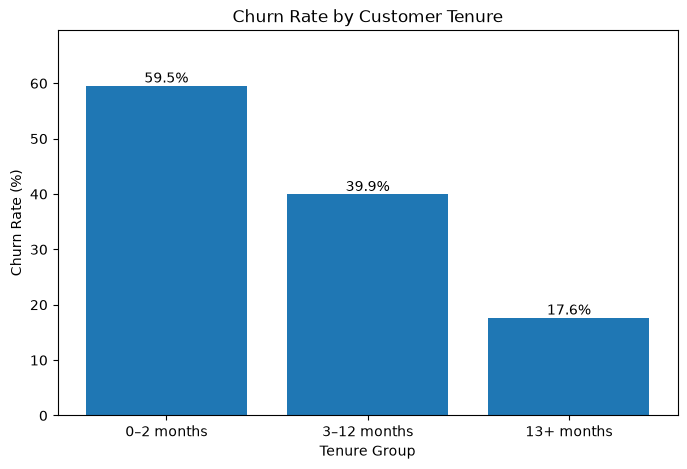

In [133]:
import matplotlib.pyplot as plt

tenure_groups = [
    '0–2 months',
    '3–12 months',
    '13+ months'
]

churn_rates = [
    churn_tenure_0_2 * 100,
    churn_tenure_2_12 * 100,
    churn_tenure_12_plus * 100
]

plt.figure(figsize=(8, 5))

bars = plt.bar(tenure_groups, churn_rates)

plt.title('Churn Rate by Customer Tenure')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, max(churn_rates) + 10)

# Display percentage above each bar
for bar, rate in zip(bars, churn_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{rate:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [139]:
tenure_churn = pd.DataFrame({
    'tenure_group': ['0–2 months', '3–12 months', '13+ months'],
    'churn_rate': [
        df_full_train[df_full_train.tenure <= 2].churn.mean(),
        df_full_train[
            (df_full_train.tenure > 2) & 
            (df_full_train.tenure <= 12)
        ].churn.mean(),
        df_full_train[df_full_train.tenure > 12].churn.mean()
    ]
})

tenure_churn

,tenure_group,churn_rate
0,0–2 months,0.595342
1,3–12 months,0.399441
2,13+ months,0.176349


In [143]:
churn_monthlycharges_0_20 = df_full_train[df_full_train.monthlycharges <= 20].churn.mean()
churn_monthlycharges_20_50 = df_full_train[
    (df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges <= 50)
].churn.mean()
churn_monthlycharges_50_plus = df_full_train[df_full_train.monthlycharges > 50].churn.mean()

print(churn_monthlycharges_0_20)
print(churn_monthlycharges_20_50)
print(churn_monthlycharges_50_plus)

0.08795411089866156
0.18340943683409436
0.32499341585462205


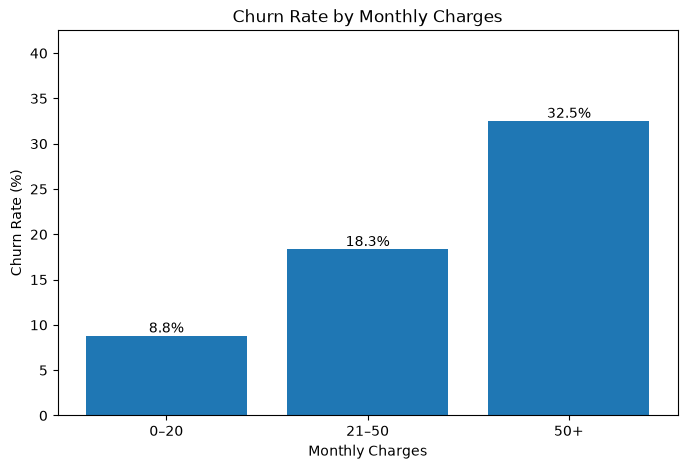

In [145]:
import matplotlib.pyplot as plt

# Calculate churn rates
churn_monthlycharges_0_20 = df_full_train[
    df_full_train.monthlycharges <= 20
].churn.mean()

churn_monthlycharges_20_50 = df_full_train[
    (df_full_train.monthlycharges > 20) &
    (df_full_train.monthlycharges <= 50)
].churn.mean()

churn_monthlycharges_50_plus = df_full_train[
    df_full_train.monthlycharges > 50
].churn.mean()

# Create groups and convert rates to percentages
monthlycharge_groups = ['0–20', '21–50', '50+']
churn_rates = [
    churn_monthlycharges_0_20 * 100,
    churn_monthlycharges_20_50 * 100,
    churn_monthlycharges_50_plus * 100
]

# Create bar chart
plt.figure(figsize=(8, 5))

bars = plt.bar(monthlycharge_groups, churn_rates)

plt.title('Churn Rate by Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, max(churn_rates) + 10)

# Add percentage labels
for bar, rate in zip(bars, churn_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{rate:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [140]:
bins = [0, 30, 50, 70, 90, 110, float('inf')]
labels = ['0–30', '31–50', '51–70', '71–90', '91–110', '110+']

df_full_train['monthlycharges_group'] = pd.cut(
    df_full_train['monthlycharges'],
    bins=bins,
    labels=labels
)

In [141]:
monthly_churn = (
    df_full_train
    .groupby('monthlycharges_group', observed=True)
    .churn
    .mean()
    .reset_index()
)

monthly_churn

,monthlycharges_group,churn
0,0–30,0.101056
1,31–50,0.299413
2,51–70,0.218143
3,71–90,0.385135
4,91–110,0.358197
5,110+,0.146199


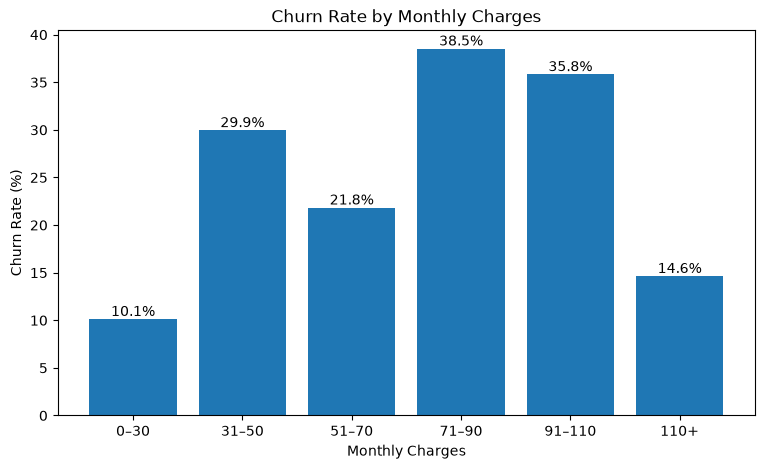

In [142]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    monthly_churn['monthlycharges_group'].astype(str),
    monthly_churn['churn'] * 100
)

plt.title('Churn Rate by Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Churn Rate (%)')

for bar, rate in zip(bars, monthly_churn['churn'] * 100):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{rate:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

# One Hot Encodding
we encode categorical features as numbers, so they can be used by a machine learning model

In [148]:
dicts = df[categorical + numerical].to_dict(orient='records')

In [149]:
from sklearn.feature_extraction import DictVectorizer

In [150]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

In [151]:
X_train.shape

(4225, 45)

## Encoding the validation set

In [155]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

## Logistic Regression
Our problem - predicting churn - is a binary classification problem: the target variable takes one of two values. We encoded it as 1 for customers who churned (the positive class) and 0 for customers who stayed (the negative class).
### The sigmoid function
The sigmoid squashes any real number into the range between 0 and 1. That turns the raw score into a probability. 

In [159]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [160]:
sigmoid(10000)

np.float64(1.0)

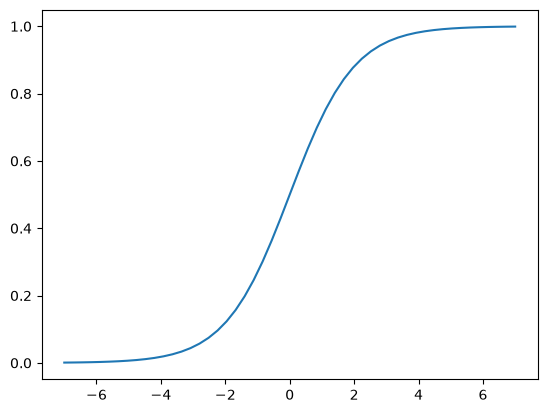

In [161]:
z = np.linspace(-7, 7, 51)
plt.plot(z, sigmoid(z))

## implementing the models

for the previous linear redression

In [162]:
def linear_regression(xi):
    result = w0
    
    for j in range(len(w)):
        result = result + xi[j] * w[j]
        
    return result

for logistic Regression

In [163]:
def logistic_regression(xi):
    score = w0
    
    for j in range(len(w)):
        score = score + xi[j] * w[j]

        
    result = sigmoid(score)  
    return result

In [182]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [183]:
y_pred = model.predict_proba(X_val_scaled)[:, 1]

In [184]:
y_pred

array([0.00682868, 0.20148678, 0.21440438, ..., 0.15211351, 0.79148001,
       0.81291145], shape=(1409,))

In [185]:
churn_decision = (y_pred >= 0.5)

In [186]:
(y_val == churn_decision).mean()

np.float64(0.8041163946061036)

In [187]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val



In [188]:
df_pred['correct'] = df_pred.prediction == df_pred.actual
df_pred.correct.mean()

np.float64(0.8041163946061036)

## Model interpretation

In [191]:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

{'contract=Month-to-month': np.float64(0.303),
 'contract=One year': np.float64(-0.021),
 'contract=Two year': np.float64(-0.334),
 'dependents=No': np.float64(0.016),
 'dependents=Yes': np.float64(-0.016),
 'deviceprotection=No': np.float64(0.041),
 'deviceprotection=No internet service': np.float64(-0.09),
 'deviceprotection=Yes': np.float64(0.036),
 'gender=Female': np.float64(0.01),
 'gender=Male': np.float64(-0.01),
 'internetservice=DSL': np.float64(-0.282),
 'internetservice=Fiber optic': np.float64(0.344),
 'internetservice=No': np.float64(-0.09),
 'monthlycharges': np.float64(-0.623),
 'multiplelines=No': np.float64(-0.093),
 'multiplelines=No phone service': np.float64(0.009),
 'multiplelines=Yes': np.float64(0.088),
 'onlinebackup=No': np.float64(0.043),
 'onlinebackup=No internet service': np.float64(-0.09),
 'onlinebackup=Yes': np.float64(0.034),
 'onlinesecurity=No': np.float64(0.119),
 'onlinesecurity=No internet service': np.float64(-0.09),
 'onlinesecurity=Yes': np.flo

### small model

In [192]:
small = ['contract', 'tenure', 'monthlycharges']

dicts_train_small = df_train[small].to_dict(orient='records')
dicts_val_small = df_val[small].to_dict(orient='records')

In [194]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

DictVectorizer(sparse=False)

In [195]:
dv_small.get_feature_names_out()

array(['contract=Month-to-month', 'contract=One year',
       'contract=Two year', 'monthlycharges', 'tenure'], dtype=object)

In [196]:
X_train_small = dv_small.transform(dicts_train_small)

model_small = LogisticRegression(solver='lbfgs')
model_small.fit(X_train_small, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [197]:
w0 = model_small.intercept_[0]
w0

np.float64(-2.477957596026966)

In [198]:
w = model_small.coef_[0]
dict(zip(dv_small.get_feature_names_out(), w.round(3)))

{'contract=Month-to-month': np.float64(0.971),
 'contract=One year': np.float64(-0.024),
 'contract=Two year': np.float64(-0.948),
 'monthlycharges': np.float64(0.027),
 'tenure': np.float64(-0.036)}

In [200]:
sigmoid(w0)

np.float64(0.0774179537975664)

# Using the model

In [201]:
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

y_full_train = df_full_train.churn.values

In [206]:
model = LogisticRegression(solver='liblinear',max_iter=1000)
model.fit(X_full_train, y_full_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalt

### Checking on the test set

In [207]:
dicts_test = df_test[categorical + numerical].to_dict(orient='records')
X_test = dv.transform(dicts_test)

y_pred = model.predict_proba(X_test)[:, 1]
churn_decision = (y_pred >= 0.5)
(churn_decision == y_test).mean()

np.float64(0.8126330731014905)

In [208]:
customer = dicts_test[-1]
customer

{'gender': 'Female',
 'seniorcitizen': 0,
 'partner': 'Yes',
 'dependents': 'Yes',
 'phoneservice': 'Yes',
 'multiplelines': 'Yes',
 'internetservice': 'Fiber optic',
 'onlinesecurity': 'Yes',
 'onlinebackup': 'No',
 'deviceprotection': 'Yes',
 'techsupport': 'No',
 'streamingtv': 'Yes',
 'streamingmovies': 'Yes',
 'contract': 'Month-to-month',
 'paperlessbilling': 'Yes',
 'paymentmethod': 'Electronic check',
 'tenure': 17,
 'monthlycharges': 104.2,
 'totalcharges': 1743.5}

In [209]:
X_small = dv.transform([customer])
model.predict_proba(X_small)[0, 1]

np.float64(0.6434116288184129)

In [210]:
y_test[-1]

np.int64(1)

In [211]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('dv.pkl', 'wb') as f:
    pickle.dump(dv, f)

In [212]:
import pickle

with open('model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('dv.pkl', 'rb') as f:
    dv = pickle.load(f)

In [216]:
customer ={'gender': 'Female',
 'seniorcitizen': 0,
 'partner': 'Yes',
 'dependents': 'Yes',
 'phoneservice': 'Yes',
 'multiplelines': 'Yes',
 'internetservice': 'Fiber optic',
 'onlinesecurity': 'Yes',
 'onlinebackup': 'No',
 'deviceprotection': 'Yes',
 'techsupport': 'No',
 'streamingtv': 'Yes',
 'streamingmovies': 'Yes',
 'contract': 'Month-to-month',
 'paperlessbilling': 'Yes',
 'paymentmethod': 'Electronic check',
 'tenure': 17,
 'monthlycharges': 104.2,
 'totalcharges': 1743.5}

In [217]:
X = dv.transform([customer])

probability = model.predict_proba(X)[0, 1]

print(f"Churn probability: {probability:.3f}")

Churn probability: 0.643


In [218]:
if probability >= 0.5:
    print("Customer is likely to churn")
else:
    print("Customer is unlikely to churn")

Customer is likely to churn
